# Fashion-MNIST: Shallow CNN vs Deep CNN Comparative Study

# Part 1: Load and Explore the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
print("Number of classes:", len(class_names))


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


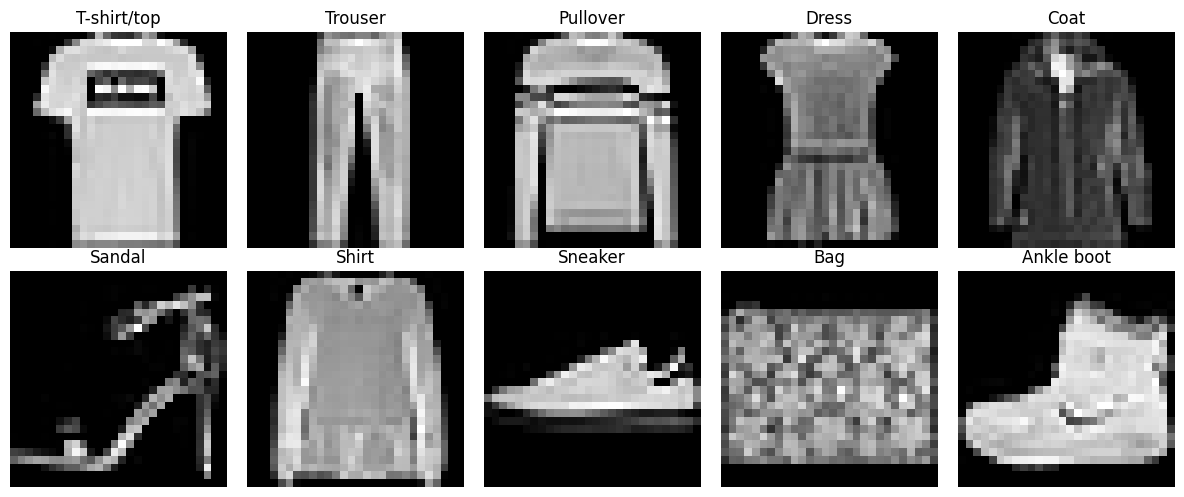

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, cls in enumerate(range(10)):
    idx = np.where(y_train == cls)[0][0]
    ax = axes[i//5, i%5]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(class_names[cls])
    ax.axis('off')

plt.tight_layout()
plt.show()


In [3]:
# Normalization

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshaping

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Reshaped training data:", x_train.shape)
print("Reshaped testing data:", x_test.shape)


Reshaped training data: (60000, 28, 28, 1)
Reshaped testing data: (10000, 28, 28, 1)


### Why is normalization required?

Normalization scales pixel values from 0–255 to 0–1. This helps neural networks converge faster, improves numerical stability, and prevents large pixel values from dominating gradient updates.

### Why do CNNs require reshaped inputs?

CNN layers expect image data in a structured format of **height × width × channels**. Fashion-MNIST images are grayscale, so they must be reshaped to **28 × 28 × 1** before being passed into convolution layers.


# Part 2: Build and Train a Shallow CNN

In [4]:
shallow_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

shallow_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_shallow = shallow_cnn.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

shallow_time = time.time() - start_time

shallow_test_loss, shallow_test_acc = shallow_cnn.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Shallow CNN Test Accuracy:", shallow_test_acc)
print("Training Time:", shallow_time)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8312 - loss: 0.4750 - val_accuracy: 0.8809 - val_loss: 0.3396
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8886 - loss: 0.3100 - val_accuracy: 0.8952 - val_loss: 0.2941
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9075 - loss: 0.2541 - val_accuracy: 0.9045 - val_loss: 0.2666
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9177 - loss: 0.2228 - val_accuracy: 0.9111 - val_loss: 0.2456
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9274 - loss: 0.1969 - val_accuracy: 0.9108 - val_loss: 0.2422
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9360 - loss: 0.1736 - val_accuracy: 0.9093 - val_loss: 0.2491
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9444 - loss: 0.1520 - val_accuracy: 0.9159 - val_loss: 0.2302
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9513 - loss: 0.1347 - val_accuracy: 0.

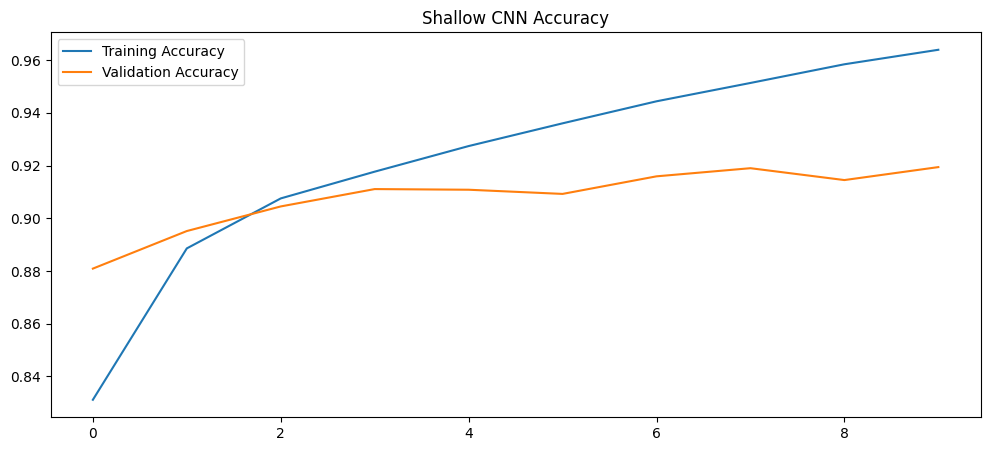

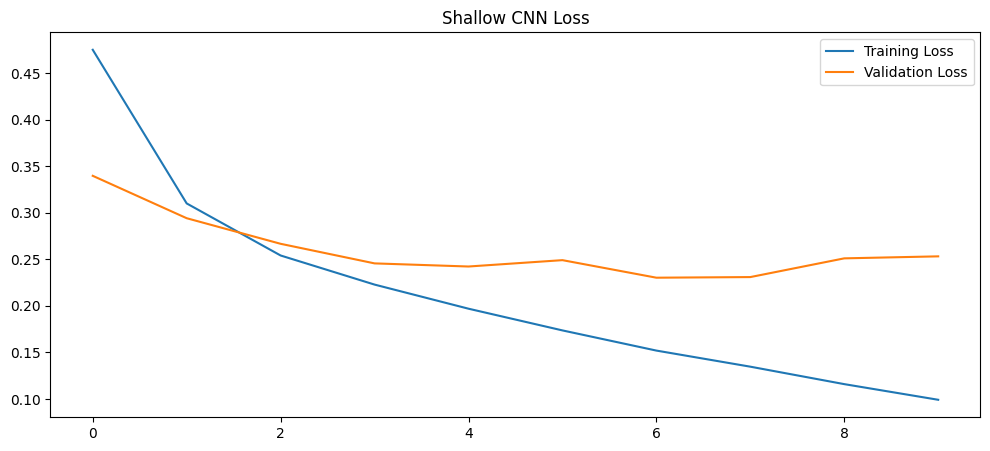

In [5]:
plt.figure(figsize=(12,5))
plt.plot(history_shallow.history['accuracy'], label='Training Accuracy')
plt.plot(history_shallow.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Shallow CNN Accuracy")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history_shallow.history['loss'], label='Training Loss')
plt.plot(history_shallow.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Shallow CNN Loss")
plt.show()


### Discussion

**Patterns learned by a shallow CNN:**

A shallow CNN generally learns low-level visual features such as edges, corners, textures, and simple clothing outlines.

**Underfitting or Overfitting:**

Compare training and validation curves. If both remain low, the model is underfitting. If training accuracy becomes much higher than validation accuracy, overfitting is occurring.


# Part 3: Build and Train a Deep CNN

In [6]:
deep_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

deep_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_deep = deep_cnn.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

deep_time = time.time() - start_time

deep_test_loss, deep_test_acc = deep_cnn.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Deep CNN Test Accuracy:", deep_test_acc)
print("Training Time:", deep_time)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7727 - loss: 0.6117 - val_accuracy: 0.8569 - val_loss: 0.3914
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8654 - loss: 0.3652 - val_accuracy: 0.8781 - val_loss: 0.3298
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8890 - loss: 0.3021 - val_accuracy: 0.8970 - val_loss: 0.2789
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9019 - loss: 0.2677 - val_accuracy: 0.9013 - val_loss: 0.2711
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9108 - loss: 0.2424 - val_accuracy: 0.9067 - val_loss: 0.2639
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9170 - loss: 0.2252 - val_accuracy: 0.9143 - val_loss: 0.2367
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9248 - loss: 0.2044 - val_accuracy: 0.9147 - val_loss: 0.2386
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9315 - loss: 0.1854 - val_accuracy: 0

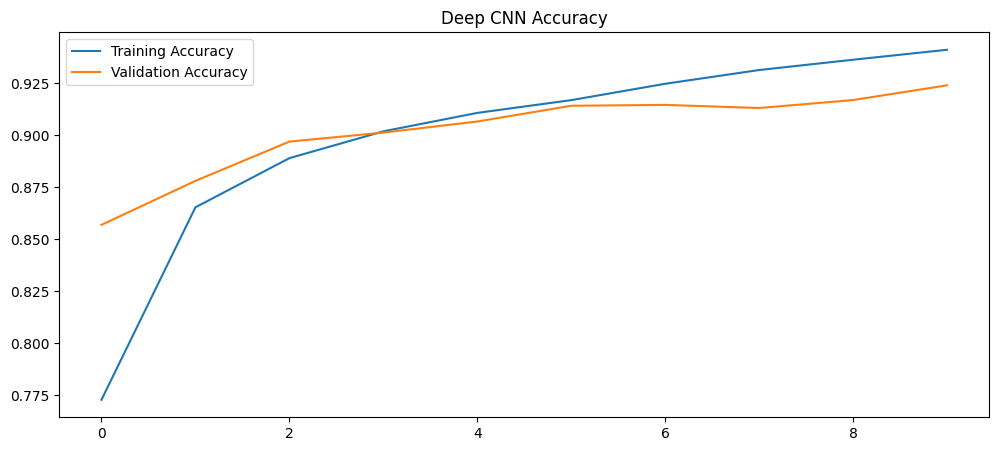

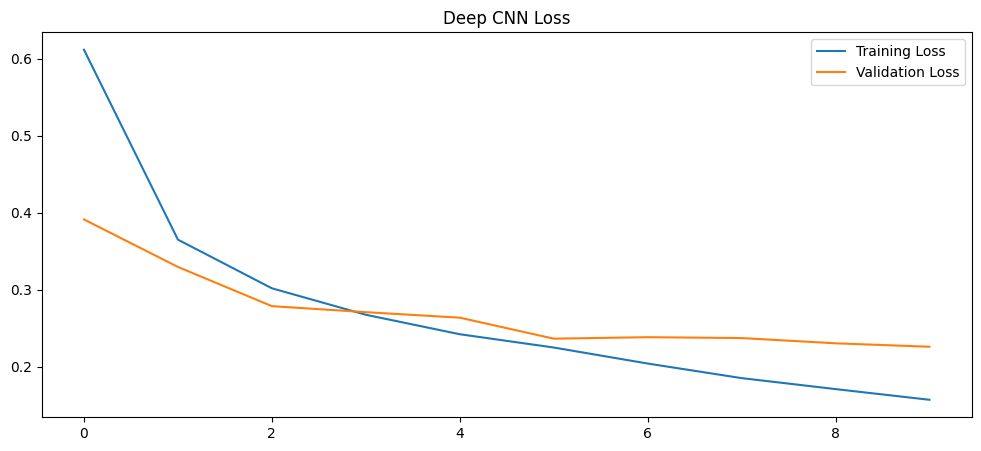

In [7]:
plt.figure(figsize=(12,5))
plt.plot(history_deep.history['accuracy'], label='Training Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Deep CNN Accuracy")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history_deep.history['loss'], label='Training Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Deep CNN Loss")
plt.show()


### Discussion

**Additional patterns learned by a deep CNN:**

A deeper network can learn hierarchical features. Early layers detect edges, middle layers identify shapes and clothing structures, and deeper layers capture high-level garment representations.

**Did performance improve?**

Compare final validation and test accuracy. Deep CNNs often achieve better performance because they learn richer feature representations.


# Part 4: Comparative Study

In [8]:
comparison = pd.DataFrame({
    'Metric':[
        'Number of Conv Layers',
        'Total Parameters',
        'Training Accuracy',
        'Validation Accuracy',
        'Test Accuracy',
        'Overfitting Observed?',
        'Training Time (sec)'
    ],
    'Shallow CNN':[
        2,
        shallow_cnn.count_params(),
        history_shallow.history['accuracy'][-1],
        history_shallow.history['val_accuracy'][-1],
        shallow_test_acc,
        'Check curves',
        round(shallow_time,2)
    ],
    'Deep CNN':[
        4,
        deep_cnn.count_params(),
        history_deep.history['accuracy'][-1],
        history_deep.history['val_accuracy'][-1],
        deep_test_acc,
        'Check curves',
        round(deep_time,2)
    ]
})

comparison


,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,2,4
1,Total Parameters,1011466,361578
2,Training Accuracy,0.963917,0.941208
3,Validation Accuracy,0.919417,0.924083
4,Test Accuracy,0.9159,0.9183
5,Overfitting Observed?,Check curves,Check curves
6,Training Time (sec),25.05,38.27


### Comparative Analysis

- The better model is the one with higher validation and test accuracy.
- Deep CNNs usually achieve better feature extraction but require more computation.
- Generalization should be judged using validation and test performance rather than training accuracy.
- A trade-off exists between simplicity, speed, and predictive performance.


# Part 5: Prediction and Error Analysis

In [9]:
shallow_pred = np.argmax(shallow_cnn.predict(x_test), axis=1)
deep_pred = np.argmax(deep_cnn.predict(x_test), axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [10]:
def show_predictions(images, true_labels, pred_labels, correct=True, n=5):
    if correct:
        idx = np.where(true_labels == pred_labels)[0][:n]
        title = "Correct Predictions"
    else:
        idx = np.where(true_labels != pred_labels)[0][:n]
        title = "Incorrect Predictions"

    plt.figure(figsize=(12,3))

    for i, sample in enumerate(idx):
        plt.subplot(1,n,i+1)
        plt.imshow(images[sample].reshape(28,28), cmap='gray')
        plt.title(f"A:{class_names[true_labels[sample]]}\nP:{class_names[pred_labels[sample]]}")
        plt.axis('off')

    plt.suptitle(title)
    plt.show()


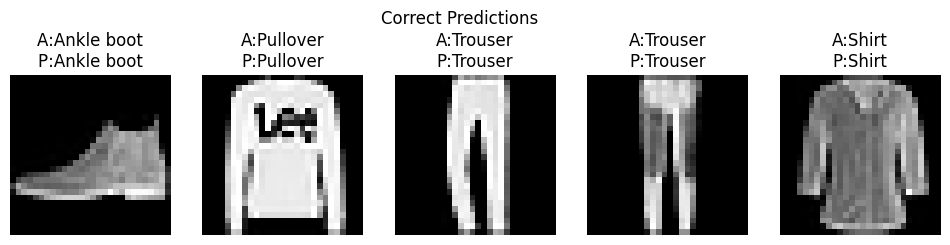

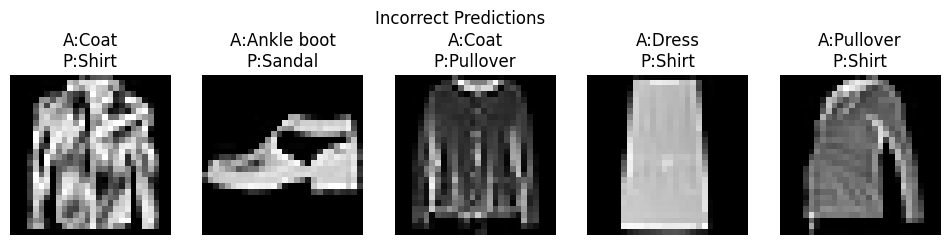

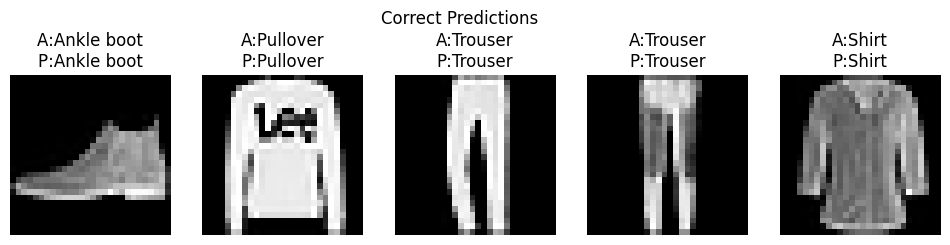

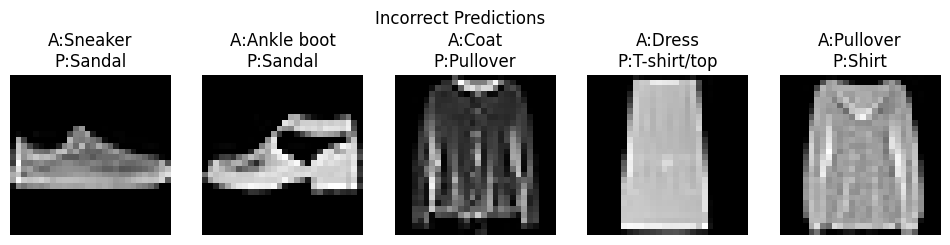

In [11]:
show_predictions(x_test, y_test, shallow_pred, True)
show_predictions(x_test, y_test, shallow_pred, False)

show_predictions(x_test, y_test, deep_pred, True)
show_predictions(x_test, y_test, deep_pred, False)


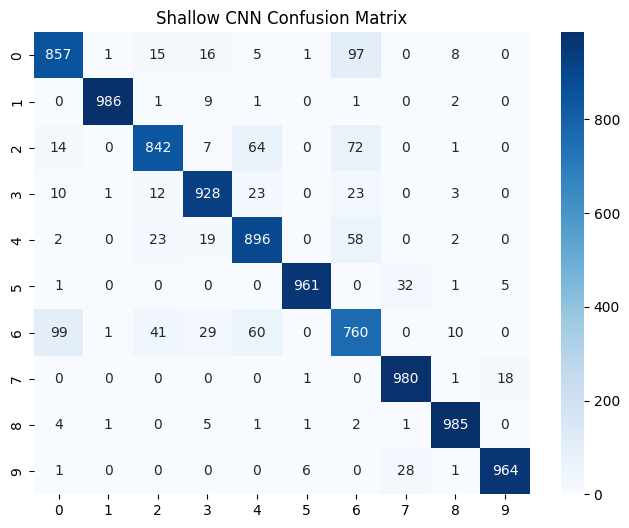

In [12]:
cm_shallow = confusion_matrix(y_test, shallow_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues')
plt.title("Shallow CNN Confusion Matrix")
plt.show()


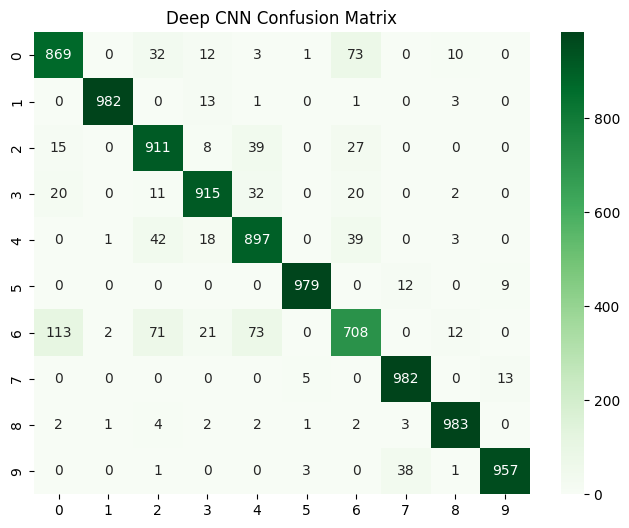

In [13]:
cm_deep = confusion_matrix(y_test, deep_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens')
plt.title("Deep CNN Confusion Matrix")
plt.show()


### Error Analysis

**Easiest classes:**

Usually Bag, Sneaker, Trouser, and Ankle Boot because they have distinctive shapes.

**Most confused classes:**

Shirt, Pullover, Coat, and T-shirt/top often share similar visual patterns.

**Did the deep CNN reduce confusion?**

Analyze the confusion matrices. A stronger deep CNN generally reduces misclassification among visually similar clothing categories.


# Part 6: Final Comparative Conclusion

### Recommended Model
The recommended model is the one that achieves the highest test accuracy while maintaining good generalization.

### Most Efficient Model
The shallow CNN is generally faster to train and uses fewer parameters.

### Most Accurate Model
The deep CNN typically achieves better classification accuracy due to richer feature extraction.

### Key Learning
This experiment demonstrates that increasing network depth can improve performance, but it also increases computational cost. Selecting a model requires balancing accuracy, training time, and complexity.
